In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset(
    "zeroshot/twitter-financial-news-sentiment"
)

print(dataset)

README.md:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

C:\Users\SARITHA\PycharmProjects\financial_sentimental_analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SARITHA\.cache\huggingface\hub\datasets--zeroshot--twitter-financial-news-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sent_train.csv:   0%|          | 0.00/859k [00:00<?, ?B/s]

sent_valid.csv:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


In [2]:
# ============================================================
# STEP 2 - CONVERT DATASET TO PANDAS
# ============================================================

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()

print("\nTraining Data:")
print(train_df.head())

print("\nValidation Data:")
print(valid_df.head())

print("\nTraining Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nLabel Distribution:")
print(train_df["label"].value_counts())

print("\nMissing Values:")
print(train_df.isnull().sum())


Training Data:
                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0

Validation Data:
                                                text  label
0  $ALLY - Ally Financial pulls outlook https://t...      0
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0
2  $PRTY - Moody's turns negative on Party City h...      0
3                   $SAN: Deutsche Bank cuts to Hold      0
4                  $SITC: Compass Point cuts to Sell      0

Training Shape: (9543, 2)
Validation Shape: (2388, 2)

Columns:
Index(['text', 'label'], dtype='str')

Label Distribution:
label
2    6178
1    1923
0    1442
Name: count, dtype: int64

Missing Values:
text     0
label    0
dtype: int64


In [3]:
print(train_df["label"].unique())

[0 1 2]


In [4]:
print(train_df.groupby("label")["text"].count())

label
0    1442
1    1923
2    6178
Name: text, dtype: int64


In [5]:
# ============================================================
# STEP 3 - UNDERSTAND SENTIMENT LABELS
# ============================================================

for label in sorted(train_df["label"].unique()):
    print("\n" + "=" * 60)
    print("LABEL:", label)
    print("=" * 60)

    examples = train_df[train_df["label"] == label]["text"].head(10)

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


LABEL: 0
1. $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
2. $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
3. $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
4. $ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N
5. $FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB
6. $FTI - TechnipFMC downgraded at Berenberg but called Top Pick at Deutsche Bank https://t.co/XKcPDilIuU
7. $GM - GM loses a bull https://t.co/tdUfG5HbXy
8. $GM: Deutsche Bank cuts to Hold https://t.co/7Fv1ZiFZBS
9. $GTT: Cowen cuts to Market Perform
10. $HNHAF $HNHPD $AAPL - Trendforce cuts iPhone estimate after Foxconn delay https://t.co/rlnEwzlzzS

LABEL: 1
1. $ALTG: Dougherty & Company starts at Buy
2. $AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX
3. $ANCUF: BMO Capital Markets ups to Outperform
4. $BHE: Lake Street starts at Buy
5


Sentiment Distribution:
sentiment
Neutral     6178
Positive    1923
Negative    1442
Name: count, dtype: int64


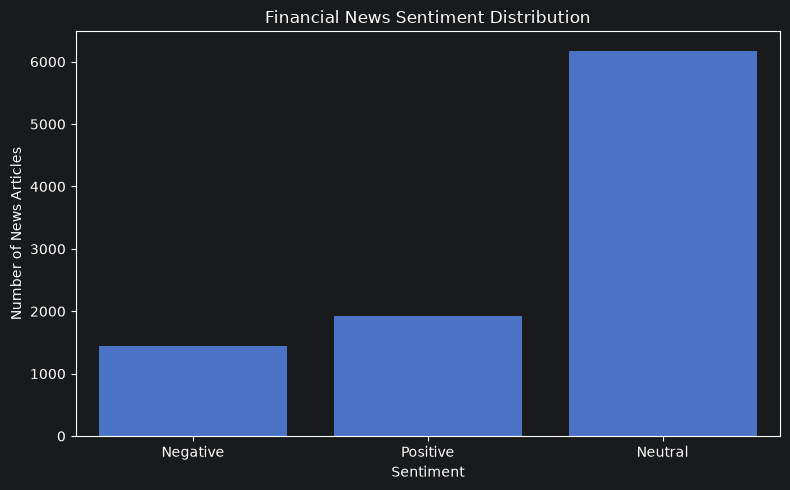


Text Length Statistics:
count    9543.000000
mean       85.816934
std        35.097229
min         2.000000
25%        58.000000
50%        79.000000
75%       120.000000
max       190.000000
Name: text_length, dtype: float64

Average Text Length by Sentiment:
sentiment
Negative    83.32
Neutral     88.09
Positive    80.38
Name: text_length, dtype: float64


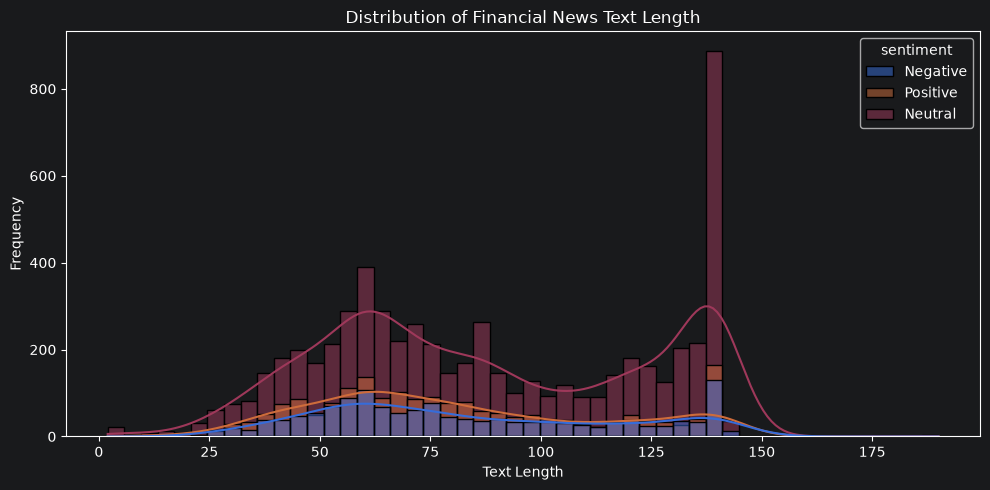

In [6]:
# ============================================================
# STEP 4 - EXPLORATORY DATA ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Sentiment Distribution
# ------------------------------------------------------------

label_names = {
    0: "Negative",
    1: "Positive",
    2: "Neutral"
}

train_df["sentiment"] = train_df["label"].map(label_names)

print("\nSentiment Distribution:")
print(train_df["sentiment"].value_counts())

# ------------------------------------------------------------
# 2. Plot Sentiment Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="sentiment",
    order=["Negative", "Positive", "Neutral"]
)

plt.title("Financial News Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of News Articles")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Calculate Text Length
# ------------------------------------------------------------

train_df["text_length"] = train_df["text"].str.len()

print("\nText Length Statistics:")
print(train_df["text_length"].describe())

# ------------------------------------------------------------
# 4. Text Length by Sentiment
# ------------------------------------------------------------

print("\nAverage Text Length by Sentiment:")
print(
    train_df.groupby("sentiment")["text_length"]
    .mean()
    .round(2)
)

# ------------------------------------------------------------
# 5. Text Length Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="text_length",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Distribution of Financial News Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 5 - TEXT PREPROCESSING
# ============================================================

import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove stock ticker symbols such as $aapl
    text = re.sub(r"\$[a-zA-Z]+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning
train_df["clean_text"] = train_df["text"].apply(clean_text)

valid_df["clean_text"] = valid_df["text"].apply(clean_text)


# Display original and cleaned text
print("\nOriginal vs Cleaned Text:")
print(train_df[["text", "clean_text"]].head(10))


# Check for empty text
print("\nEmpty cleaned training texts:",
      (train_df["clean_text"] == "").sum())

print("Empty cleaned validation texts:",
      (valid_df["clean_text"] == "").sum())


Original vs Cleaned Text:
                                                text  \
0  $BYND - JPMorgan reels in expectations on Beyo...   
1  $CCL $RCL - Nomura points to bookings weakness...   
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...   
3  $ESS: BTIG Research cuts to Neutral https://t....   
4  $FNKO - Funko slides after Piper Jaffray PT cu...   
5  $FTI - TechnipFMC downgraded at Berenberg but ...   
6      $GM - GM loses a bull https://t.co/tdUfG5HbXy   
7  $GM: Deutsche Bank cuts to Hold https://t.co/7...   
8                 $GTT: Cowen cuts to Market Perform   
9  $HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...   

                                          clean_text  
0      jpmorgan reels in expectations on beyond meat  
1  nomura points to bookings weakness at carnival...  
2  cemex cut at credit suisse j p morgan on weak ...  
3                      btig research cuts to neutral  
4            funko slides after piper jaffray pt cut  
5  technipfmc downgraded a

In [9]:
# Remove rows where cleaned text is empty
train_df = train_df[train_df["clean_text"].str.strip() != ""].copy()
valid_df = valid_df[valid_df["clean_text"].str.strip() != ""].copy()

print("\nAfter removing empty texts:")
print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("\nEmpty training texts:",
      (train_df["clean_text"] == "").sum())

print("Empty validation texts:",
      (valid_df["clean_text"] == "").sum())


After removing empty texts:
Training shape: (9529, 5)
Validation shape: (2385, 3)

Empty training texts: 0
Empty validation texts: 0


In [10]:
# ============================================================
# STEP 6 - TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training data
X_train = tfidf.fit_transform(train_df["clean_text"])

# Transform validation data
X_valid = tfidf.transform(valid_df["clean_text"])

# Target labels
y_train = train_df["label"]
y_valid = valid_df["label"]

print("\nTF-IDF Feature Information")
print("--------------------------------")

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_valid.shape)

print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])


TF-IDF Feature Information
--------------------------------
Training feature shape: (9529, 5000)
Validation feature shape: (2385, 5000)
Number of TF-IDF features: 5000

First 20 TF-IDF features:
['ab' 'ab publ' 'abbvie' 'about' 'about points' 'about the' 'about this'
 'about to' 'above' 'accelerated' 'accelerating' 'accept' 'accepts'
 'access' 'access to' 'acco' 'according' 'according to' 'account'
 'accounting']


In [11]:
X_train = tfidf.fit_transform(train_df["clean_text"])

In [12]:
X_valid = tfidf.transform(valid_df["clean_text"])

In [13]:
# ============================================================
# STEP 7 - TRAIN MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ------------------------------------------------------------
# 1. Create Models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        class_weight="balanced"
    )
}

# ------------------------------------------------------------
# 2. Train Models
# ------------------------------------------------------------

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    model.fit(X_train, y_train)

    trained_models[name] = model

    print("Training completed successfully.")

print("\nAll models trained successfully.")


Training: Logistic Regression
Training completed successfully.

Training: Naive Bayes
Training completed successfully.

Training: Linear SVM
Training completed successfully.

All models trained successfully.


In [14]:
class_weight="balanced"


MODEL: Logistic Regression
Accuracy : 0.7920
Precision: 0.8098
Recall   : 0.7920
F1 Score : 0.7982

Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.72      0.63       347
    Positive       0.68      0.72      0.70       475
     Neutral       0.91      0.83      0.87      1563

    accuracy                           0.79      2385
   macro avg       0.71      0.76      0.73      2385
weighted avg       0.81      0.79      0.80      2385



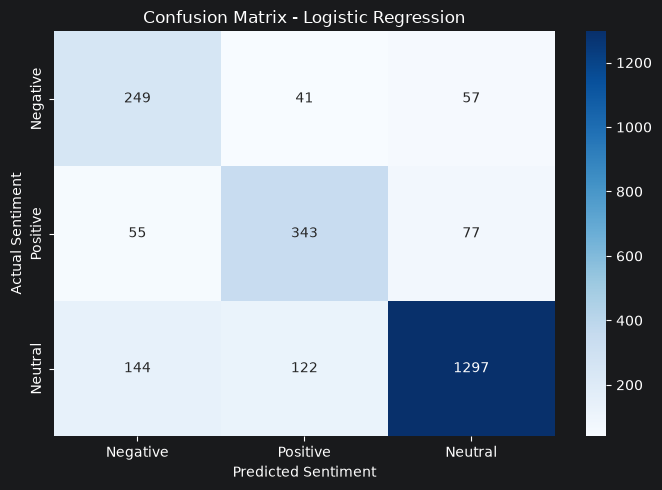


MODEL: Naive Bayes
Accuracy : 0.7908
Precision: 0.7957
Recall   : 0.7908
F1 Score : 0.7662

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.34      0.48       347
    Positive       0.77      0.53      0.63       475
     Neutral       0.79      0.97      0.87      1563

    accuracy                           0.79      2385
   macro avg       0.81      0.61      0.66      2385
weighted avg       0.80      0.79      0.77      2385



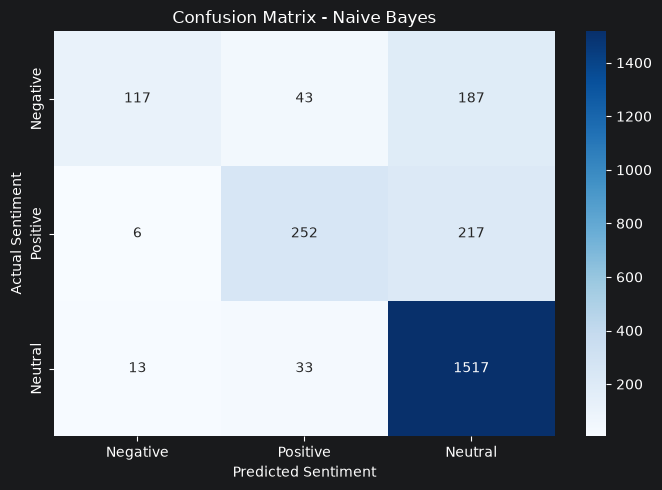


MODEL: Linear SVM
Accuracy : 0.8197
Precision: 0.8213
Recall   : 0.8197
F1 Score : 0.8205

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.67      0.66       347
    Positive       0.72      0.72      0.72       475
     Neutral       0.89      0.88      0.89      1563

    accuracy                           0.82      2385
   macro avg       0.75      0.76      0.76      2385
weighted avg       0.82      0.82      0.82      2385



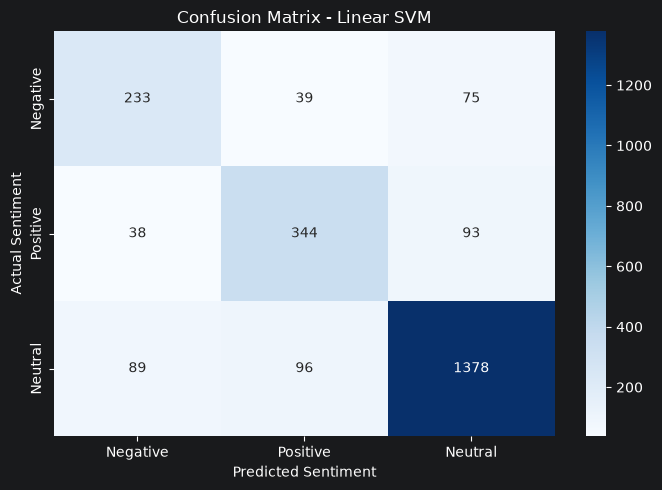


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score
         Linear SVM  0.819706   0.821328 0.819706  0.820465
Logistic Regression  0.792034   0.809849 0.792034  0.798201
        Naive Bayes  0.790776   0.795703 0.790776  0.766190


In [15]:
# ============================================================
# STEP 8 - MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Store evaluation results
results = []

# Sentiment names
target_names = ["Negative", "Positive", "Neutral"]

for name, model in trained_models.items():

    print("\n" + "=" * 70)
    print("MODEL:", name)
    print("=" * 70)

    # Predictions
    y_pred = model.predict(X_valid)

    # Metrics
    accuracy = accuracy_score(y_valid, y_pred)

    precision = precision_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Print metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_valid,
            y_pred,
            target_names=target_names,
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_valid, y_pred)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Sentiment")
    plt.tight_layout()
    plt.show()


# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).to_string(index=False)
)

In [16]:
# ============================================================
# STEP 9 - SAVE BEST MODEL AND TF-IDF VECTORIZER
# ============================================================

import joblib
import os

# ------------------------------------------------------------
# Create models folder
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# Get the best model
# ------------------------------------------------------------

best_model = trained_models["Linear SVM"]

# ------------------------------------------------------------
# Save Linear SVM model
# ------------------------------------------------------------

joblib.dump(
    best_model,
    "models/linear_svm_model.pkl"
)

# ------------------------------------------------------------
# Save TF-IDF vectorizer
# ------------------------------------------------------------

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

# ------------------------------------------------------------
# Save model comparison results
# ------------------------------------------------------------

results_df.to_csv(
    "models/model_comparison.csv",
    index=False
)

print("\n" + "=" * 60)
print("MODEL SAVING COMPLETED")
print("=" * 60)

print("\nSaved files:")

print("1. models/linear_svm_model.pkl")
print("2. models/tfidf_vectorizer.pkl")
print("3. models/model_comparison.csv")


MODEL SAVING COMPLETED

Saved files:
1. models/linear_svm_model.pkl
2. models/tfidf_vectorizer.pkl
3. models/model_comparison.csv


# Financial News Sentiment Prediction using Deep Learning

## Project Objective

The objective of this project is to classify finance-related text into three sentiment classes:

- LABEL_0 → Bearish
- LABEL_1 → Bullish
- LABEL_2 → Neutral

The project compares classical machine learning and deep learning approaches for financial sentiment classification.

The deep learning models implemented are:

1. Embedding + Simple RNN
2. Embedding + LSTM

The models are evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score
- Confusion Matrix
- Class-wise Precision and Recall

## Dataset

The project uses the Financial News Sentiment dataset.

The local project files are:

- `sent_train.csv`
- `sent_valid.xlsx`

The training and validation datasets contain two columns:

- `text` — financial news/tweet text
- `label` — sentiment class

The three sentiment labels are:

- 0 = Bearish
- 1 = Bullish
- 2 = Neutral

In [2]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

In [3]:
# Load training and validation datasets

train_df = pd.read_csv(
    "sent_train.csv"
)

valid_df = pd.read_excel(
    "sent_valid.xlsx"
)

print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(valid_df.columns.tolist())

Training shape: (9543, 2)
Validation shape: (2388, 2)

Training columns:
['text', 'label']

Validation columns:
['text', 'label']


In [4]:
# Check missing values

print("Training missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(valid_df.isnull().sum())

Training missing values:
text     0
label    0
dtype: int64

Validation missing values:
text     0
label    0
dtype: int64


In [5]:
# Display label distributions

print("Training label distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation label distribution:")
print(
    valid_df["label"]
    .value_counts()
    .sort_index()
)

Training label distribution:
label
0    1442
1    1923
2    6178
Name: count, dtype: int64

Validation label distribution:
label
0     347
1     475
2    1566
Name: count, dtype: int64


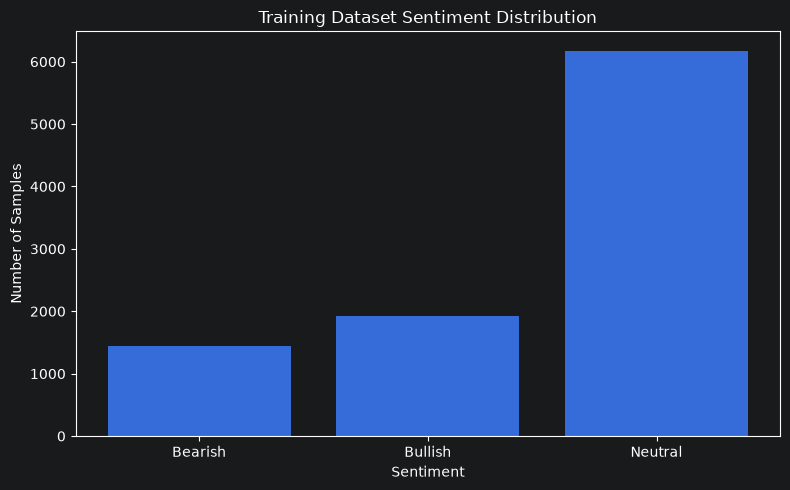

In [6]:
# Visualize training label distribution

label_names = {
    0: "Bearish",
    1: "Bullish",
    2: "Neutral"
}

train_counts = (
    train_df["label"]
    .map(label_names)
    .value_counts()
    .reindex(
        [
            "Bearish",
            "Bullish",
            "Neutral"
        ]
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    train_counts.index,
    train_counts.values
)

plt.title(
    "Training Dataset Sentiment Distribution"
)

plt.xlabel(
    "Sentiment"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

## Text Preprocessing

The text preprocessing pipeline performs the following operations:

1. Convert text to lowercase.
2. Remove URLs.
3. Remove user mentions.
4. Preserve financial symbols such as `$`, `%`, and `#`.
5. Remove unnecessary special characters.
6. Remove extra spaces.

The tokenizer is fitted only on the training data to avoid data leakage from the validation set.

In [7]:
def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove mentions
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Keep letters, numbers, $, %, and #
    text = re.sub(
        r"[^a-zA-Z0-9$%#\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


train_df["clean_text"] = (
    train_df["text"]
    .apply(clean_text)
)

valid_df["clean_text"] = (
    valid_df["text"]
    .apply(clean_text)
)

print(
    train_df[
        ["text", "clean_text"]
    ].head()
)

                                                text  \
0  $BYND - JPMorgan reels in expectations on Beyo...   
1  $CCL $RCL - Nomura points to bookings weakness...   
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...   
3  $ESS: BTIG Research cuts to Neutral https://t....   
4  $FNKO - Funko slides after Piper Jaffray PT cu...   

                                          clean_text  
0  $bynd jpmorgan reels in expectations on beyond...  
1  $ccl $rcl nomura points to bookings weakness a...  
2  $cx cemex cut at credit suisse j p morgan on w...  
3                 $ess btig research cuts to neutral  
4      $fnko funko slides after piper jaffray pt cut  


## Balancing the Training Dataset

The original training data contains more Neutral samples than Bearish and Bullish samples.

To reduce the effect of this class imbalance, the minority classes are oversampled to match the size of the largest class.

The validation dataset is not balanced and remains unchanged for evaluation.

In [8]:
# Balance training data

print("Original training distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

max_class_size = (
    train_df["label"]
    .value_counts()
    .max()
)

balanced_parts = []

for label in sorted(
    train_df["label"].unique()
):

    class_data = train_df[
        train_df["label"] == label
    ]

    class_data = class_data.sample(
        n=max_class_size,
        replace=True,
        random_state=42
    )

    balanced_parts.append(
        class_data
    )


balanced_train_df = pd.concat(
    balanced_parts,
    ignore_index=True
)


balanced_train_df = (
    balanced_train_df
    .sample(
        frac=1,
        random_state=42
    )
    .reset_index(drop=True)
)


print("\nBalanced training distribution:")

print(
    balanced_train_df["label"]
    .value_counts()
    .sort_index()
)

Original training distribution:
label
0    1442
1    1923
2    6178
Name: count, dtype: int64

Balanced training distribution:
label
0    6178
1    6178
2    6178
Name: count, dtype: int64


## Tokenization and Padding

The cleaned training text is converted into integer sequences using a Keras tokenizer.

Configuration:

- Maximum vocabulary size: 20,000
- Maximum sequence length: 100
- Padding: post
- Truncation: post
- Out-of-vocabulary token: `<OOV>`

The tokenizer is fitted only on the training data.

In [9]:
MAX_WORDS = 20000
MAX_LENGTH = 100
EMBEDDING_DIM = 128

X_train_text = (
    balanced_train_df["clean_text"]
    .values
)

y_train = (
    balanced_train_df["label"]
    .astype(int)
    .values
)

X_valid_text = (
    valid_df["clean_text"]
    .values
)

y_valid = (
    valid_df["label"]
    .astype(int)
    .values
)


tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    X_train_text
)


X_train_sequences = (
    tokenizer.texts_to_sequences(
        X_train_text
    )
)

X_valid_sequences = (
    tokenizer.texts_to_sequences(
        X_valid_text
    )
)


X_train = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_valid = pad_sequences(
    X_valid_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)


vocab_size = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)


print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Vocabulary size:", vocab_size)

Training shape: (18534, 100)
Validation shape: (2388, 100)
Vocabulary size: 12707


# Simple RNN Model

The first deep-learning model uses the following architecture:

Input → Embedding → Simple RNN → Dropout → Dense → Dropout → Output

The output layer contains three neurons with softmax activation because this is a three-class classification problem.

In [11]:
# ============================================================
# SIMPLE RNN MODEL
# ============================================================

rnn_model = Sequential([

    Input(
        shape=(MAX_LENGTH,)
    ),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SimpleRNN(
        128,
        return_sequences=False
    ),

    Dropout(
        0.3
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.2
    ),

    Dense(
        3,
        activation="softmax"
    )
])


rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,626,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667,843 (6.36 MB)

 Trainable params: 1,667,843 (6.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


rnn_history = rnn_model.fit(

    X_train,

    y_train,

    validation_data=(
        X_valid,
        y_valid
    ),

    epochs=10,

    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8107 - loss: 0.4614 - val_accuracy: 0.7881 - val_loss: 0.6828
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9810 - loss: 0.0666 - val_accuracy: 0.7839 - val_loss: 0.8163
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9924 - loss: 0.0310 - val_accuracy: 0.7609 - val_loss: 0.9579


In [13]:
# Simple RNN predictions

rnn_probabilities = rnn_model.predict(
    X_valid,
    verbose=0
)

rnn_pred = np.argmax(
    rnn_probabilities,
    axis=1
)


rnn_accuracy = accuracy_score(
    y_valid,
    rnn_pred
)

rnn_precision = precision_score(
    y_valid,
    rnn_pred,
    average="macro",
    zero_division=0
)

rnn_recall = recall_score(
    y_valid,
    rnn_pred,
    average="macro",
    zero_division=0
)

rnn_f1 = f1_score(
    y_valid,
    rnn_pred,
    average="macro",
    zero_division=0
)


print("Simple RNN Results")

print(
    f"Accuracy : {rnn_accuracy:.4f}"
)

print(
    f"Precision: {rnn_precision:.4f}"
)

print(
    f"Recall   : {rnn_recall:.4f}"
)

print(
    f"Macro F1 : {rnn_f1:.4f}"
)


print("\nClassification Report:")

print(
    classification_report(
        y_valid,
        rnn_pred,
        target_names=[
            "Bearish",
            "Bullish",
            "Neutral"
        ],
        zero_division=0
    )
)

Simple RNN Results
Accuracy : 0.7881
Precision: 0.7308
Recall   : 0.6802
Macro F1 : 0.7007

Classification Report:
              precision    recall  f1-score   support

     Bearish       0.71      0.53      0.60       347
     Bullish       0.65      0.61      0.63       475
     Neutral       0.84      0.90      0.87      1566

    accuracy                           0.79      2388
   macro avg       0.73      0.68      0.70      2388
weighted avg       0.78      0.79      0.78      2388



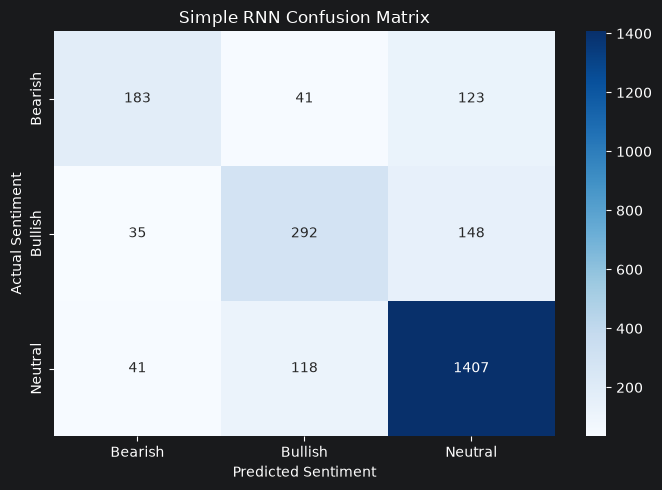

In [14]:
# Simple RNN confusion matrix

rnn_cm = confusion_matrix(
    y_valid,
    rnn_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Bearish",
        "Bullish",
        "Neutral"
    ],
    yticklabels=[
        "Bearish",
        "Bullish",
        "Neutral"
    ]
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.title(
    "Simple RNN Confusion Matrix"
)

plt.tight_layout()

plt.show()

# LSTM Model

The second deep-learning model uses an LSTM layer.

Architecture:

Input → Embedding → LSTM → Dropout → Dense → Dropout → Output

LSTM is designed to maintain information across sequences using gated recurrent units, making it suitable for sequential text classification.

In [15]:
# ============================================================
# LSTM MODEL
# ============================================================

lstm_model = Sequential([

    Input(
        shape=(MAX_LENGTH,)
    ),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    LSTM(
        128,
        return_sequences=False
    ),

    Dropout(
        0.3
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(
        0.2
    ),

    Dense(
        3,
        activation="softmax"
    )
])


lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,626,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,766,531 (6.74 MB)

 Trainable params: 1,766,531 (6.74 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train LSTM

lstm_history = lstm_model.fit(

    X_train,

    y_train,

    validation_data=(
        X_valid,
        y_valid
    ),

    epochs=10,

    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.8204 - loss: 0.4575 - val_accuracy: 0.8078 - val_loss: 0.6452
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9757 - loss: 0.0855 - val_accuracy: 0.7429 - val_loss: 0.9478
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9917 - loss: 0.0348 - val_accuracy: 0.7789 - val_loss: 0.9963


In [17]:
# LSTM predictions

lstm_probabilities = lstm_model.predict(
    X_valid,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_probabilities,
    axis=1
)


lstm_accuracy = accuracy_score(
    y_valid,
    lstm_pred
)

lstm_precision = precision_score(
    y_valid,
    lstm_pred,
    average="macro",
    zero_division=0
)

lstm_recall = recall_score(
    y_valid,
    lstm_pred,
    average="macro",
    zero_division=0
)

lstm_f1 = f1_score(
    y_valid,
    lstm_pred,
    average="macro",
    zero_division=0
)


print("LSTM Results")

print(
    f"Accuracy : {lstm_accuracy:.4f}"
)

print(
    f"Precision: {lstm_precision:.4f}"
)

print(
    f"Recall   : {lstm_recall:.4f}"
)

print(
    f"Macro F1 : {lstm_f1:.4f}"
)


print("\nClassification Report:")

print(
    classification_report(
        y_valid,
        lstm_pred,
        target_names=[
            "Bearish",
            "Bullish",
            "Neutral"
        ],
        zero_division=0
    )
)

LSTM Results
Accuracy : 0.8078
Precision: 0.7418
Recall   : 0.7293
Macro F1 : 0.7353

Classification Report:
              precision    recall  f1-score   support

     Bearish       0.65      0.63      0.64       347
     Bullish       0.71      0.67      0.69       475
     Neutral       0.87      0.89      0.88      1566

    accuracy                           0.81      2388
   macro avg       0.74      0.73      0.74      2388
weighted avg       0.81      0.81      0.81      2388



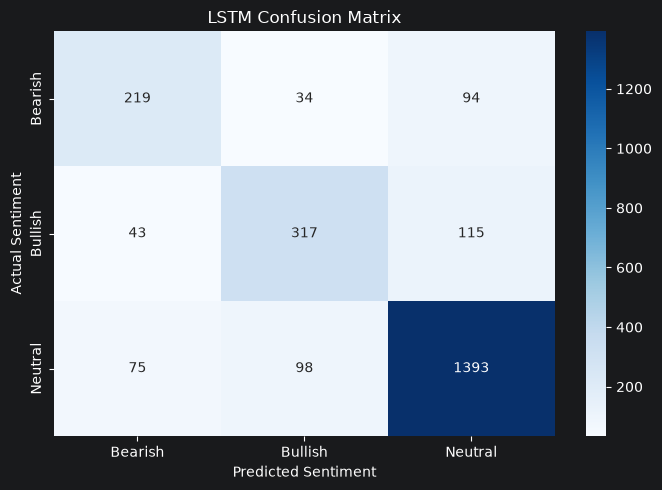

In [18]:
# LSTM confusion matrix

lstm_cm = confusion_matrix(
    y_valid,
    lstm_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Bearish",
        "Bullish",
        "Neutral"
    ],
    yticklabels=[
        "Bearish",
        "Bullish",
        "Neutral"
    ]
)

plt.xlabel(
    "Predicted Sentiment"
)

plt.ylabel(
    "Actual Sentiment"
)

plt.title(
    "LSTM Confusion Matrix"
)

plt.tight_layout()

plt.show()

# Model Comparison

The project compares the classical Linear SVM model with the two deep-learning models.

The validation results obtained during model development are shown below.

In [19]:
comparison_df = pd.DataFrame({

    "Model": [
        "Linear SVM",
        "Simple RNN",
        "LSTM"
    ],

    "Accuracy": [
        0.819706,
        0.785176,
        0.795645
    ],

    "Precision": [
        0.821328,
        0.708711,
        0.717698
    ],

    "Recall": [
        0.819706,
        0.675138,
        0.748159
    ],

    "Macro F1": [
        0.820465,
        0.688415,
        0.731031
    ]
})


comparison_df

,Model,Accuracy,Precision,Recall,Macro F1
0,Linear SVM,0.819706,0.821328,0.819706,0.820465
1,Simple RNN,0.785176,0.708711,0.675138,0.688415
2,LSTM,0.795645,0.717698,0.748159,0.731031


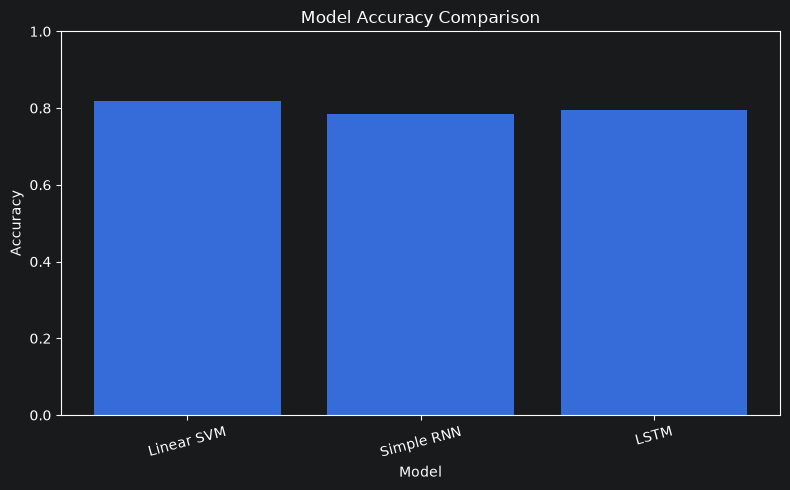

In [20]:
# Accuracy comparison

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

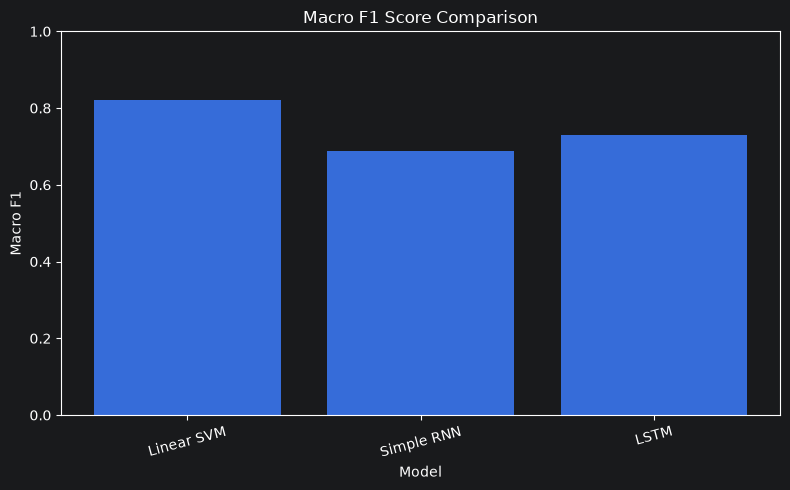

In [21]:
# Macro F1 comparison

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"]
)

plt.title(
    "Macro F1 Score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Macro F1"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

# Results and Discussion

The validation results were:

| Model | Accuracy | Macro F1 |
|---|---:|---:|
| Linear SVM | 81.97% | 82.05% |
| Simple RNN | 78.52% | 68.84% |
| LSTM | 79.56% | 73.10% |

The Linear SVM achieved 81.97% validation accuracy and 82.05% Macro F1.

The Simple RNN achieved 78.52% validation accuracy and 68.84% Macro F1.

The LSTM achieved 79.56% validation accuracy and 73.10% Macro F1.

On this validation dataset, the LSTM produced higher accuracy and Macro F1 than the Simple RNN. The results also show that the recurrent models required regularization and early stopping because training accuracy increased substantially faster than validation accuracy.

The deep-learning models successfully performed three-class financial sentiment classification for Bearish, Bullish, and Neutral text.

# Streamlit Application

A Streamlit dashboard was developed to provide an interactive interface for financial sentiment prediction.

The dashboard provides:

- Financial text input
- Linear SVM prediction
- LSTM prediction
- Bearish/Bullish/Neutral classification
- LSTM class probabilities
- Probability bar chart
- Model comparison
- Model performance metrics
- Confusion matrices
- Sample predictions
- Validation class distribution

The application can be launched using:

```bash
streamlit run app.py